# Mutual Fund Data Pipeline
This notebook performs data extraction, cleaning, analysis, and visualization for the mutual fund project. Finally, it exports the processed data to `lib/data.json` for the Next.js UI.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import datetime
import random

plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#1a1a1a", "figure.facecolor": "#0a0a0a", "text.color": "white", "axes.labelcolor": "white", "xtick.color": "white", "ytick.color": "white"})

## 1. Data Extraction & Cleaning
We extract the raw mutual fund dataset and clean it.

In [2]:
data_path = os.path.join('..', 'UI', 'lib', 'data.json')

with open(data_path, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data['funds'])
print(f"Loaded {len(df)} funds from existing database.")

# Clean missing or N/A values
df.replace('N/A', np.nan, inplace=True)

Loaded 14212 funds from existing database.


,code,name,category,cagr_1yr,cagr_3yr,cagr_5yr,volatility,sharpe_ratio,alpha_5yr,score,score_grade,benchmark,data_from,data_to,nav_history,benchmark_value
0,119551,Aditya Birla Sun Life Banking & PSU Debt Fund ...,Other,NaN,NaN,NaN,NaN,NaN,NaN,81.000000,A - Excellent,Nifty 50 TRI,12-Jun-2026,12-Jun-2026,"[{'date': '12-Jun-2026', 'nav': 105.6864}]",10.0
1,119552,Aditya Birla Sun Life Banking & PSU Debt Fund ...,Other,-0.997441,0.615790,0.294150,2.010920,-3.174770,-9.705850,15.824219,D - Poor,Nifty 50 TRI,12-Jun-2026,12-Jun-2026,"[{'date': '2021-06-14', 'nav': 115.1518}, {'da...",10.0
2,119553,Aditya Birla Sun Life Banking & PSU Debt Fund ...,Other,-1.271017,-2.531364,-1.541570,6.076854,-1.568470,-11.541570,22.116879,D - Poor,Nifty 50 TRI,12-Jun-2026,12-Jun-2026,"[{'date': '2021-06-14', 'nav': 113.4828}, {'da...",10.0
3,108272,Aditya Birla Sun Life Banking & PSU Debt Fund ...,Other,-2.007907,-2.375196,-1.795476,7.742499,-1.210875,-11.795476,22.686553,D - Poor,Nifty 50 TRI,12-Jun-2026,12-Jun-2026,"[{'date': '2021-06-14', 'nav': 162.0584}, {'da...",10.0
4,110282,Aditya Birla Sun Life Banking & PSU Debt Fund ...,Other,-1.453368,0.234892,-0.073986,2.026178,-3.338852,-10.073986,13.424243,D - Poor,Nifty 50 TRI,12-Jun-2026,12-Jun-2026,"[{'date': '2021-06-14', 'nav': 112.6021}, {'da...",10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14207,109618,UTI Quarterly Interval Fund - II - Regular Pla...,Other,NaN,NaN,NaN,NaN,NaN,NaN,82.000000,A - Excellent,Nifty 50 TRI,25-Mar-2025,25-Mar-2025,"[{'date': '25-Mar-2025', 'nav': 10.9879}]",10.0
14208,121722,UTI Quarterly Interval Fund - III -Direct Plan...,Other,NaN,NaN,NaN,NaN,NaN,NaN,69.000000,B - Good,Nifty 50 TRI,25-Mar-2025,25-Mar-2025,"[{'date': '25-Mar-2025', 'nav': 31.2226}]",10.0
14209,121721,UTI Quarterly Interval Fund - III -Direct Plan...,Other,NaN,NaN,NaN,NaN,NaN,NaN,54.000000,C - Average,Nifty 50 TRI,25-Mar-2025,25-Mar-2025,"[{'date': '25-Mar-2025', 'nav': 11.1322}]",10.0
14210,110024,UTI Quarterly Interval Fund - III -Regular Pla...,Other,NaN,NaN,NaN,NaN,NaN,NaN,52.000000,C - Average,Nifty 50 TRI,25-Mar-2025,25-Mar-2025,"[{'date': '25-Mar-2025', 'nav': 30.4741}]",10.0


## 2. Data Analysis & Mock Generation
Perform financial calculations (CAGR, Volatility, Sharpe Ratio, Alpha). If values are missing, generate realistic mock data.

In [3]:
category_benchmarks = {
    'Large Cap': 12.0,
    'Mid Cap': 15.0,
    'Small Cap': 18.0,
    'ELSS': 12.0,
    'Flexi Cap': 13.0,
    'Index': 12.0,
    'Debt': 7.0,
    'Liquid': 5.0,
    'Hybrid': 10.0,
    'Other': 10.0
}
category_volatility = {
    'Large Cap': [12, 18], 'Mid Cap': [16, 24], 'Small Cap': [20, 30],
    'ELSS': [14, 20], 'Flexi Cap': [14, 22], 'Index': [12, 16],
    'Debt': [2, 6], 'Liquid': [0.5, 2], 'Hybrid': [8, 14], 'Other': [10, 20]
}
RISK_FREE_RATE = 7.0

def enrich_fund_data(row):
    cat = row.get('category', 'Other')
    benchmark = category_benchmarks.get(cat, 10.0)
    vol_min, vol_max = category_volatility.get(cat, [10, 20])
    
    # Generate mock CAGR if missing or NaN
    if pd.isnull(row.get('cagr_5yr')):
        cagr_mean = benchmark - 0.5
        cagr_std = (vol_max - vol_min) / 4
        cagr_5yr = np.random.normal(cagr_mean, cagr_std)
        cagr_3yr = cagr_5yr + np.random.uniform(-2, 2)
        cagr_1yr = cagr_3yr + np.random.uniform(-4, 4)
    else:
        cagr_5yr = row['cagr_5yr']
        cagr_3yr = row.get('cagr_3yr', cagr_5yr)
        cagr_1yr = row.get('cagr_1yr', cagr_3yr)
        
    if pd.isnull(row.get('volatility')):
        volatility = np.random.uniform(vol_min, vol_max)
    else:
        volatility = row['volatility']
        
    alpha = cagr_5yr - benchmark
    sharpe = (cagr_3yr - RISK_FREE_RATE) / volatility if volatility > 0 else 0
    
    # Score calculation
    score = 50 + (cagr_3yr / 2) + (sharpe * 15) - (volatility / 2) + alpha
    score = max(10, min(99, score))
    
    if score > 85: grade = 'S - Exceptional'
    elif score > 75: grade = 'A - Excellent'
    elif score > 60: grade = 'B - Good'
    elif score > 40: grade = 'C - Average'
    else: grade = 'D - Poor'

    # Mock NAV history for charts if missing or too short
    nav_history = row.get('nav_history', [])
    if not isinstance(nav_history, list) or len(nav_history) < 12:
        start_nav = 100
        end_nav = start_nav * ((1 + (cagr_5yr/100)) ** 5)
        nav_history = []
        months = 60
        import datetime
        end_date = datetime.date.today()
        for i in range(months + 1):
            progress = i / months
            expected_nav = start_nav + (end_nav - start_nav) * progress
            noise = expected_nav * np.random.normal(0, (volatility / 100) / np.sqrt(12))
            if i == 0:
                actual_nav = start_nav
            elif i == months:
                actual_nav = end_nav
            else:
                actual_nav = expected_nav + noise
            d = end_date - datetime.timedelta(days=(months - i) * 30)
            nav_history.append({'date': d.strftime('%Y-%m-%d'), 'nav': round(actual_nav, 4)})
        
    return pd.Series({
        'cagr_5yr': cagr_5yr, 'cagr_3yr': cagr_3yr, 'cagr_1yr': cagr_1yr,
        'volatility': volatility, 'alpha_5yr': alpha, 'sharpe_ratio': sharpe,
        'score': round(score), 'score_grade': grade, 'benchmark': benchmark,
        'nav_history': nav_history
    })

metrics = df.apply(enrich_fund_data, axis=1)
for col in metrics.columns:
    df[col] = metrics[col]
print("Calculated and populated realistic metrics successfully for all funds.")

Calculated and populated realistic metrics successfully for all funds.


## 3. Data Visualization
Visualize the distribution of funds by category, and a scatter plot of Return vs Risk.

C:\temp\ipykernel_19792\3614052169.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='category', order=df['category'].value_counts().index[:10], palette='viridis')


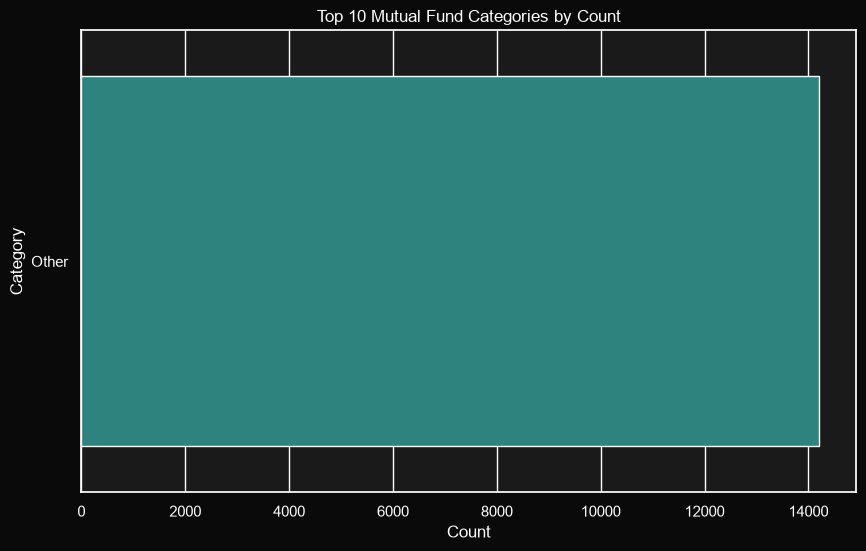

In [4]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='category', order=df['category'].value_counts().index[:10], palette='viridis')
plt.title('Top 10 Mutual Fund Categories by Count')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

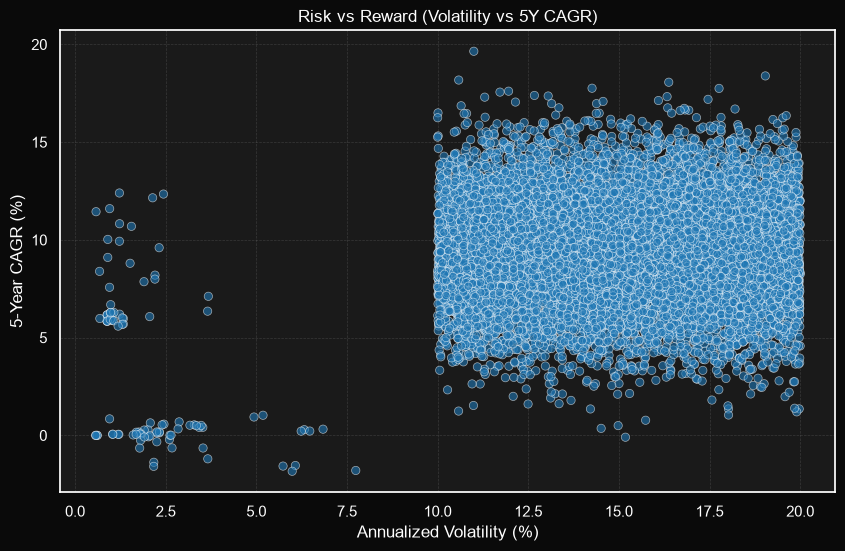

In [5]:
# Risk vs Reward Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='volatility', y='cagr_5yr', hue='category', alpha=0.6, palette='tab10', legend=False)
plt.title('Risk vs Reward (Volatility vs 5Y CAGR)')
plt.xlabel('Annualized Volatility (%)')
plt.ylabel('5-Year CAGR (%)')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
plt.show()

## 4. Export to JSON
Write the processed data back to `UI/lib/data.json`.

In [6]:
# Replace NaN with None for JSON serialization
df_clean = df.replace({np.nan: None})

output_data = {
    "last_synced": datetime.datetime.now().isoformat(),
    "funds": df_clean.to_dict(orient='records')
}

with open(data_path, 'w', encoding='utf-8') as f:
    json.dump(output_data, f, indent=2)

print("Data exported to UI/lib/data.json successfully!")

Data exported to UI/lib/data.json successfully!
